# Vectors and Matrices

*Dimensions, feature order, and observation alignment.*

A vector is an ordered sequence of numeric values. A matrix arranges values in a rectangular grid. Python lists represent these structures here.


## A Vector of Measurements

The `minutes` field supplies one value per student-day observation. Vector positions follow record order.


In [1]:
study_records = [
    {"student_id": "S01", "day": "Mon", "minutes": 30, "tasks": 2, "score": 70},
    {"student_id": "S02", "day": "Mon", "minutes": 45, "tasks": 3, "score": 80},
    {"student_id": "S01", "day": "Tue", "minutes": 40, "tasks": 4, "score": 75},
]

minutes_vector = [record["minutes"] for record in study_records]

print("Minutes vector:", minutes_vector)
print("Vector length:", len(minutes_vector))
print("Second value:", minutes_vector[1])


Minutes vector: [30, 45, 40]
Vector length: 3
Second value: 45


`[30, 45, 40]` contains three measurements. Position `1` holds S02's Monday duration, `45`.


## A Matrix of Observations and Features

- Rows: student-day observations.
- Columns: `minutes`, then `tasks`.
- Dimensions: `(number of observations, number of features)`.
- Every row has the same number of features in the same order.

Each inner list stores one row; the outer list stores all rows. Scores form a separate, aligned target vector.


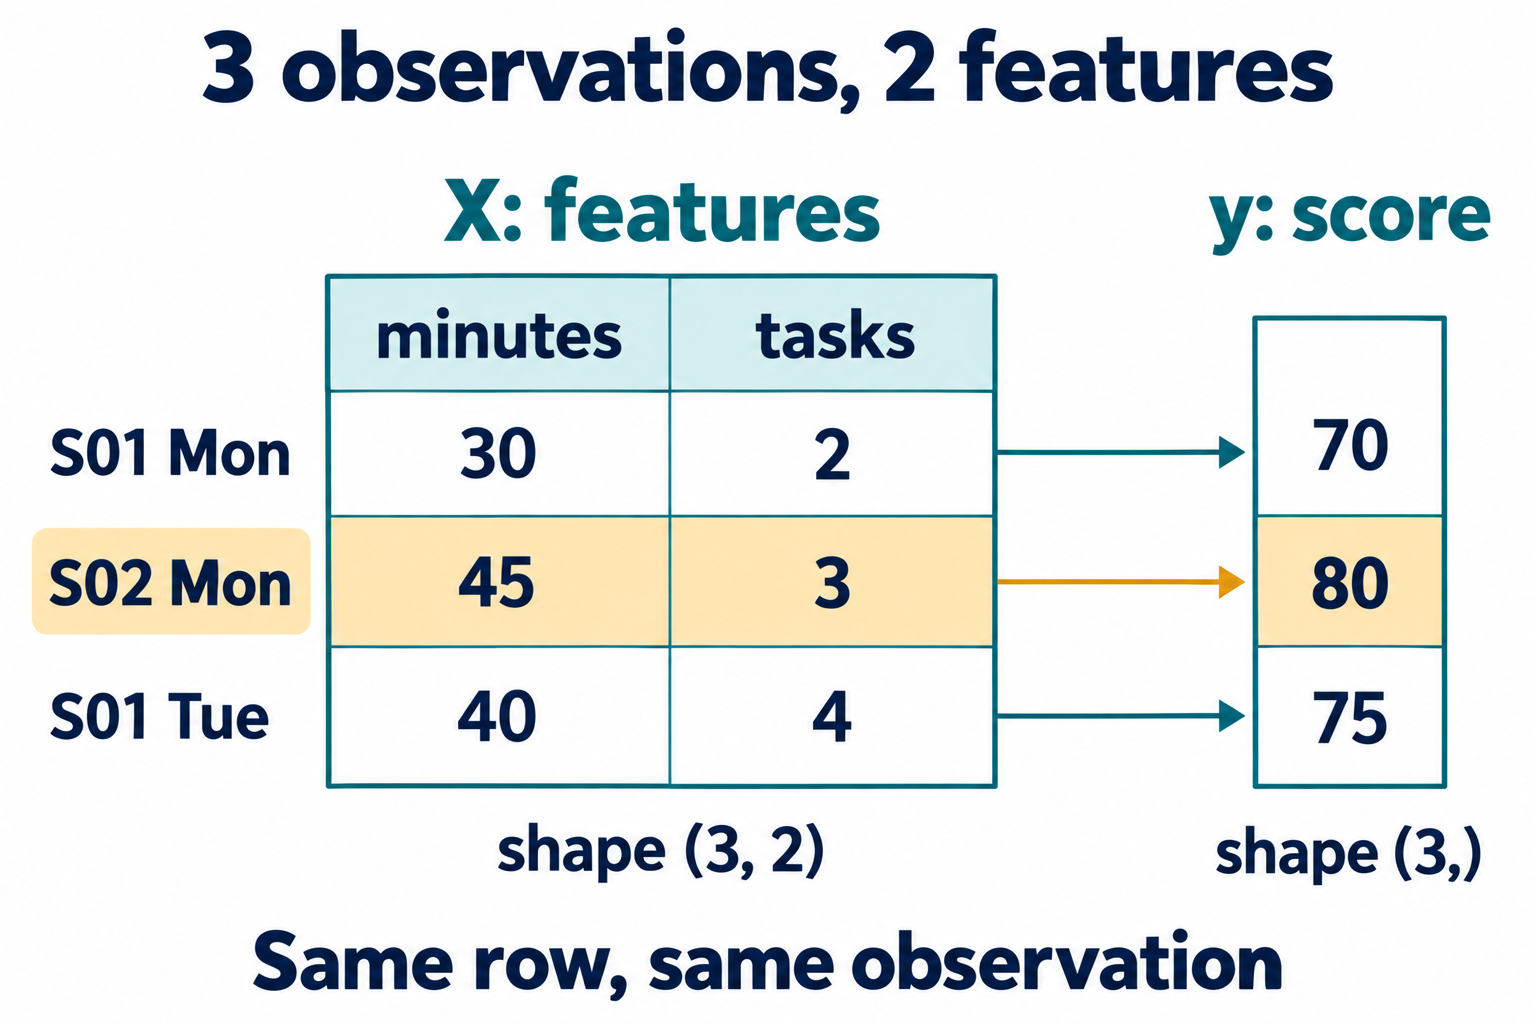

`X`: three observations × two features. `y`: three target values, aligned with the same observations.


In [2]:
feature_names = ["minutes", "tasks"]
feature_rows = [[record["minutes"], record["tasks"]] for record in study_records]
observation_count = len(feature_rows)
feature_count = len(feature_names)

print("Feature order:", feature_names)
print("Feature matrix:", feature_rows)
print("Matrix dimensions:", (observation_count, feature_count))
print("Second observation:", feature_rows[1])
print("Third observation, first feature:", feature_rows[2][0])


Feature order: ['minutes', 'tasks']
Feature matrix: [[30, 2], [45, 3], [40, 4]]
Matrix dimensions: (3, 2)
Second observation: [45, 3]
Third observation, first feature: 40


The matrix has dimensions `(3, 2)`. Row `1` is `[45, 3]`; element `[2][0]` is `40`.


## Rows, Columns, and Axes

| Coordinate | Meaning | Selection |
| --- | --- | --- |
| First index; axis 0 in a NumPy array | Observation position | `feature_rows[1]` selects a row |
| Second index; axis 1 in a NumPy array | Feature position | `[row[0] for row in feature_rows]` collects a column |

The nested list requires a comprehension to collect a column. The matrix dimensions follow axis order: observations, then features.


In [3]:
minutes_column = [row[0] for row in feature_rows]
tasks_column = [row[1] for row in feature_rows]

print("Minutes column:", minutes_column)
print("Tasks column:", tasks_column)
print("Values per column:", len(minutes_column))


Minutes column: [30, 45, 40]
Tasks column: [2, 3, 4]
Values per column: 3


Each column has three values, one per observation. The first column reproduces `minutes_vector`.


## Features, Targets, and Alignment

| Role | Fields | Representation |
| --- | --- | --- |
| Identity | `student_id`, `day` | Observation keys |
| Input features, conventionally `X` | `minutes`, `tasks` | Matrix with dimensions `(3, 2)` |
| Numeric target, conventionally `y` | `score` | Vector with dimensions `(3,)` |

`(3,)` denotes one dimension of length three. A matrix row and its target must describe the same observation; identity labels remain separate from the numeric inputs.


In [4]:
observation_keys = [(record["student_id"], record["day"]) for record in study_records]
target_scores = [record["score"] for record in study_records]

print("Target vector:", target_scores)
print("Target dimensions:", (len(target_scores),))
for position in range(len(study_records)):
    print(observation_keys[position], feature_rows[position], target_scores[position])


Target vector: [70, 80, 75]
Target dimensions: (3,)
('S01', 'Mon') [30, 2] 70
('S02', 'Mon') [45, 3] 80
('S01', 'Tue') [40, 4] 75


S02's Monday row `[45, 3]` corresponds to score `80`. The score is stored only in the target vector.


## Reordering Complete Observations

Sorting complete records preserves the association between identity, features, and target. Sorting only the feature rows can break that association.

`key=lambda record: record["minutes"]` selects study duration as the sort key. The feature and target sequences are then extracted from the same ordered records.


In [5]:
ordered_records = sorted(study_records, key=lambda record: record["minutes"])
ordered_keys = [(record["student_id"], record["day"]) for record in ordered_records]
ordered_features = [[record["minutes"], record["tasks"]] for record in ordered_records]
ordered_targets = [record["score"] for record in ordered_records]

print("Ordered observation keys:", ordered_keys)
print("Ordered feature matrix:", ordered_features)
print("Aligned target vector:", ordered_targets)


Ordered observation keys: [('S01', 'Mon'), ('S01', 'Tue'), ('S02', 'Mon')]
Ordered feature matrix: [[30, 2], [40, 4], [45, 3]]
Aligned target vector: [70, 75, 80]


The minute values become `[30, 40, 45]`; the corresponding targets become `[70, 75, 80]`. S02's feature row and target move together to the final position.


Matrix dimensions describe observation count and feature count. Feature order and observation identity must remain consistent across numeric arrays and model inputs.
